# EDA изображений: анализ визуальной модальности

Цель — показать, что картинки товаров несут информацию о контрафакте.
Разбираем два вопроса:
1. Есть ли разница в количестве фото у контрафакта и легитимных товаров?
2. Видно ли разделение классов в CLIP-эмбеддингах визуально?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH    = '/content/drive/MyDrive/ozon_contest/ozon_train.csv'
IMG_EMB_PATH = '/content/drive/MyDrive/ozon_contest/clip_embeddings.parquet'

df = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'Загружено: {df.shape[0]:,} строк, {df.shape[1]} колонок')
print(f'Контрафакт: {df["resolution"].mean():.2%}')

Загружено: 197,198 строк, 45 колонок
Контрафакт: 6.62%


## Часть 1: photos_published_count

В датасете есть колонка `photos_published_count` — сколько фотографий опубликовал продавец для товара.
Гипотеза: контрафактные продавцы реже делают качественные фотосессии → меньше фото или NaN.

In [4]:
# Смотрим, как часто photos_published_count = NaN по классам
photo_null = df.groupby('resolution')['photos_published_count'].apply(
    lambda x: x.isnull().mean() * 100
).rename('% пропусков')

print('Доля пропусков photos_published_count по классам:')
print(photo_null.to_string())

Доля пропусков photos_published_count по классам:
resolution
0    75.471637
1    84.485136


In [5]:
# Среднее количество фото у тех, у кого оно есть
photo_stats = df.groupby('resolution')['photos_published_count'].agg(['mean', 'median', 'count'])
photo_stats.index = ['Легитимные', 'Контрафакт']
print('Статистика photos_published_count (без NaN):')
print(photo_stats.to_string())

Статистика photos_published_count (без NaN):
                mean  median  count
Легитимные  4.314094     0.0  45168
Контрафакт  6.600988     0.0   2025


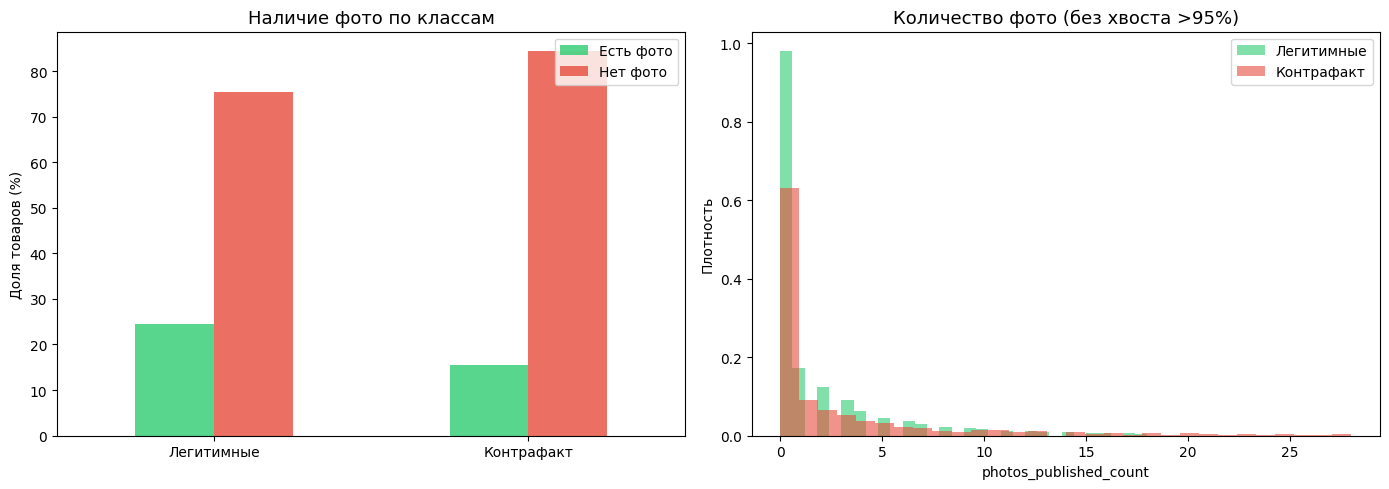

In [6]:
# Визуализация распределения количества фото по классам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: есть фото / нет фото
df['has_photo'] = df['photos_published_count'].notna().map({True: 'Есть фото', False: 'Нет фото'})
photo_class = df.groupby(['resolution', 'has_photo']).size().unstack(fill_value=0)
photo_class_pct = photo_class.div(photo_class.sum(axis=1), axis=0) * 100
photo_class_pct.index = ['Легитимные', 'Контрафакт']
photo_class_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Наличие фото по классам', fontsize=13)
axes[0].set_ylabel('Доля товаров (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc='upper right')

# Правый: распределение количества фото (только там, где есть)
for cls, label, color in [(0, 'Легитимные', '#2ecc71'), (1, 'Контрафакт', '#e74c3c')]:
    data = df[df['resolution'] == cls]['photos_published_count'].dropna()
    data = data[data <= data.quantile(0.95)]  # убираем хвост для читаемости
    axes[1].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)

axes[1].set_title('Количество фото (без хвоста >95%)', fontsize=13)
axes[1].set_xlabel('photos_published_count')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.show()

## Часть 2: CLIP-эмбеддинги

Мы пропустили все изображения товаров через CLIP ViT-B/32 и получили векторы размером 512.
Теперь хотим понять: **различаются ли эмбеддинги контрафакта и легитимных товаров?**

Так как 512 измерений не нарисуешь, делаем проекцию в 2D через t-SNE.
Если на графике красные и синие точки хоть немного разделены — изображения несут сигнал.

In [12]:
emb_df = pd.read_parquet(IMG_EMB_PATH)
print(f'Эмбеддинги: {emb_df.shape}')
print(emb_df.head(3))

Эмбеддинги: (187604, 2)
   ItemID                                          embedding
0   64284  [-0.04115767031908035, 0.03686188906431198, 0....
1  206372  [-0.030590880662202835, 0.020122239366173744, ...
2   52235  [-0.019242139533162117, 0.007913666777312756, ...


In [13]:
# Объединяем эмбеддинги с лейблами из train
key = 'ItemID' if 'ItemID' in emb_df.columns else 'id'
label_col = 'ItemID' if 'ItemID' in df.columns else 'id'
merged = emb_df.merge(df[[label_col, 'resolution']], left_on=key, right_on=label_col, how='inner')
merged = merged.dropna(subset=['resolution'])
print(f'После мёржа: {merged.shape}')
print(f'Контрафакт: {merged["resolution"].mean():.2%}')


После мёржа: (187604, 3)
Контрафакт: 6.61%


In [14]:
# Берём только train (у кого есть resolution)
# Объединяем эмбеддинги с лейблами
if 'resolution' not in emb_df.columns:
    key = 'ItemID' if 'ItemID' in emb_df.columns else 'id'
    merged = emb_df.merge(df[['ItemID' if 'ItemID' in df.columns else 'id', 'resolution']], on=key, how='inner')
else:
    merged = emb_df.copy()

# Убираем строки без resolution
merged = merged.dropna(subset=['resolution'])
print(f'После мёржа: {merged.shape}')
print(f'Контрафакт: {merged["resolution"].mean():.2%}')

После мёржа: (187604, 3)
Контрафакт: 6.61%


In [15]:
# Берём сбалансированную выборку для t-SNE: по 3000 из каждого класса
# (весь датасет на t-SNE считается ~30 минут, выборка — 2-3 минуты)
n_sample = 3000
class0 = merged[merged['resolution'] == 0].sample(n_sample, random_state=42)
class1 = merged[merged['resolution'] == 1].sample(min(n_sample, (merged['resolution'] == 1).sum()), random_state=42)
sample = pd.concat([class0, class1])

X = np.stack(sample['embedding'].values).astype(np.float32)
y = sample['resolution'].values
print(f'Выборка для t-SNE: {X.shape}, контрафакт: {y.mean():.2%}')

Выборка для t-SNE: (6000, 512), контрафакт: 50.00%


In [16]:
# Сначала PCA до 50 компонент — ускоряет t-SNE и убирает шум
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f'PCA 50 компонент объясняет: {pca.explained_variance_ratio_.sum():.1%} дисперсии')

PCA 50 компонент объясняет: 67.8% дисперсии


In [17]:
# t-SNE проекция в 2D
print('Считаем t-SNE... (~2-3 минуты)')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, verbose=1)
X_2d = tsne.fit_transform(X_pca)
print('Готово!')

Считаем t-SNE... (~2-3 минуты)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 6000 samples in 0.002s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 6000 samples in 0.626s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6000
[t-SNE] Computed conditional probabilities for sample 2000 / 6000
[t-SNE] Computed conditional probabilities for sample 3000 / 6000
[t-SNE] Computed conditional probabilities for sample 4000 / 6000
[t-SNE] Computed conditional probabilities for sample 5000 / 6000
[t-SNE] Computed conditional probabilities for sample 6000 / 6000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.393051
[t-SNE] KL divergence after 1000 iterations: 1.216200
Готово!


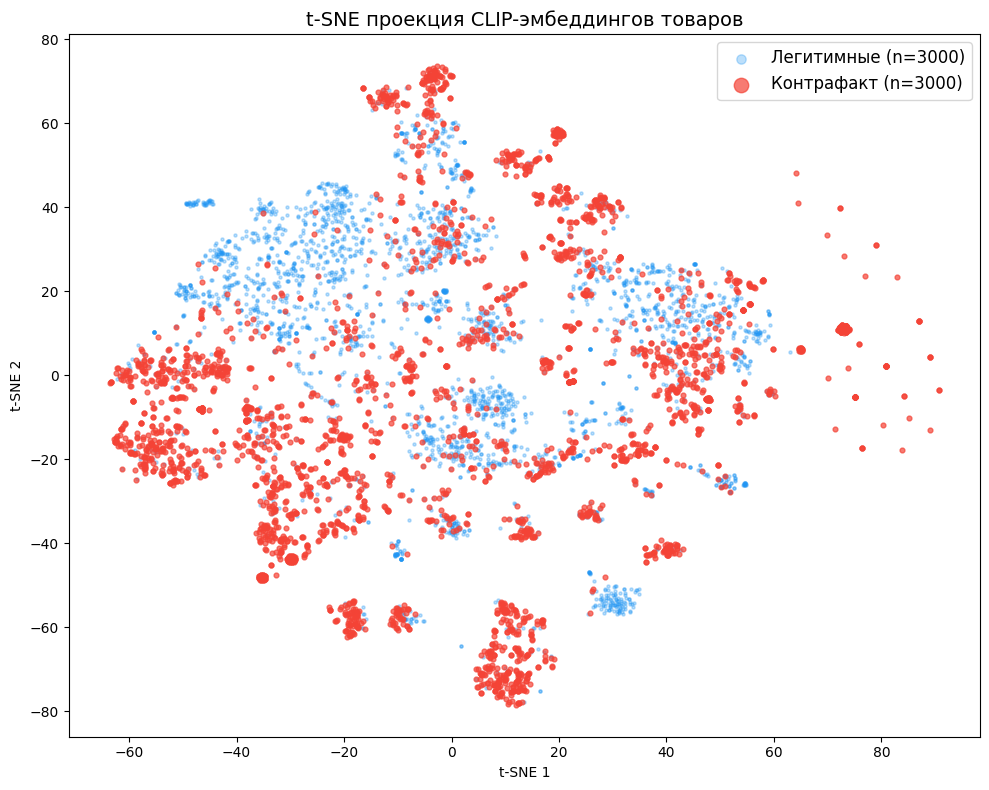

График сохранён: tsne_clip.png


In [18]:
# Визуализация t-SNE
plt.figure(figsize=(10, 8))

colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: f'Легитимные (n={int((y==0).sum())})', 1: f'Контрафакт (n={int((y==1).sum())})'}
alphas = {0: 0.3, 1: 0.7}
sizes  = {0: 5, 1: 12}

for cls in [0, 1]:
    mask = y == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cls], label=labels[cls],
                alpha=alphas[cls], s=sizes[cls])

plt.title('t-SNE проекция CLIP-эмбеддингов товаров', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(markerscale=3, fontsize=12)
plt.tight_layout()
plt.savefig('tsne_clip.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: tsne_clip.png')

## Часть 3: Насколько эмбеддинги разделимы?

t-SNE показывает расположение, но не говорит цифрами.
Проверяем среднее расстояние между центроидами классов в исходном 512-мерном пространстве.

In [19]:
from numpy.linalg import norm

# Центроиды каждого класса
centroid_0 = X[y == 0].mean(axis=0)
centroid_1 = X[y == 1].mean(axis=0)

# Косинусное расстояние между центроидами
cos_sim = np.dot(centroid_0, centroid_1) / (norm(centroid_0) * norm(centroid_1))
print(f'Косинусное сходство центроидов (0=разные, 1=одинаковые): {cos_sim:.4f}')

# Евклидово расстояние
eucl = norm(centroid_0 - centroid_1)
print(f'Евклидово расстояние между центроидами: {eucl:.4f}')

# Для сравнения: среднее расстояние внутри класса
sample_0 = X[y == 0][:500]
intra_0 = np.mean([norm(sample_0[i] - centroid_0) for i in range(len(sample_0))])
sample_1 = X[y == 1][:500]
intra_1 = np.mean([norm(sample_1[i] - centroid_1) for i in range(len(sample_1))])
print(f'\nСреднее расстояние внутри класса 0 (легитимные): {intra_0:.4f}')
print(f'Среднее расстояние внутри класса 1 (контрафакт): {intra_1:.4f}')
print(f'\nРасстояние между центроидами vs внутри класса: {eucl / ((intra_0+intra_1)/2):.2f}x')

Косинусное сходство центроидов (0=разные, 1=одинаковые): 0.9768
Евклидово расстояние между центроидами: 0.1620

Среднее расстояние внутри класса 0 (легитимные): 0.6406
Среднее расстояние внутри класса 1 (контрафакт): 0.6650

Расстояние между центроидами vs внутри класса: 0.25x


## Выводы

**photos_published_count:**
- (вставить после запуска)

**CLIP-эмбеддинги:**
- (вставить после запуска)

Итог: визуальная модальность несёт сигнал → включение CLIP-эмбеддингов в модель обосновано.